Korak 1:
State: [0.97 0.23 0.16 0.48 0.84 0.92 0.16 0.17 0.77 0.73 0.67 0.54 0.72 0.37
 0.25]
Akcija: [0, 3, 0]
Objašnjenje: {'pit': 'Nema pit stopa – dovoljno guma', 'compound': 'Compound kod: 3', 'style': 'Konzervativno'}
Reward: 2.96
----------------------------------------
Korak 2:
State: [0.18 0.73 0.25 0.19 0.19 0.44 0.77 0.52 0.56 0.1  0.47 0.45 0.13 0.01
 0.31]
Akcija: [0, 3, 0]
Objašnjenje: {'pit': 'Nema pit stopa – dovoljno guma', 'compound': 'Compound kod: 3', 'style': 'Konzervativno'}
Reward: 2.99
----------------------------------------
Korak 3:
State: [0.57 0.03 0.78 0.27 0.65 0.76 0.33 0.32 0.56 0.03 0.64 0.   0.   0.45
 0.28]
Akcija: [0, 3, 0]
Objašnjenje: {'pit': 'Nema pit stopa – dovoljno guma', 'compound': 'Compound kod: 3', 'style': 'Konzervativno'}
Reward: 2.91
----------------------------------------
Korak 4:
State: [0.3  0.32 0.04 0.14 0.64 0.63 0.78 0.12 0.72 0.26 0.48 0.69 0.65 0.33
 0.78]
Akcija: [0, 3, 0]
Objašnjenje: {'pit': 'Nema pit stopa – dovoljno guma',

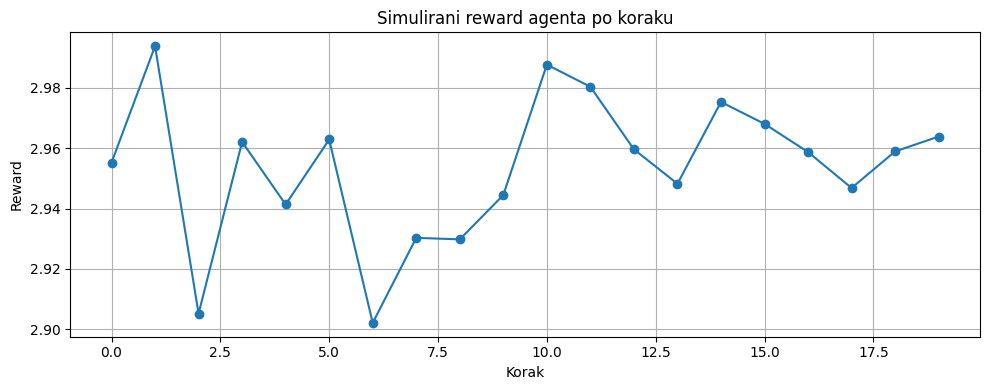

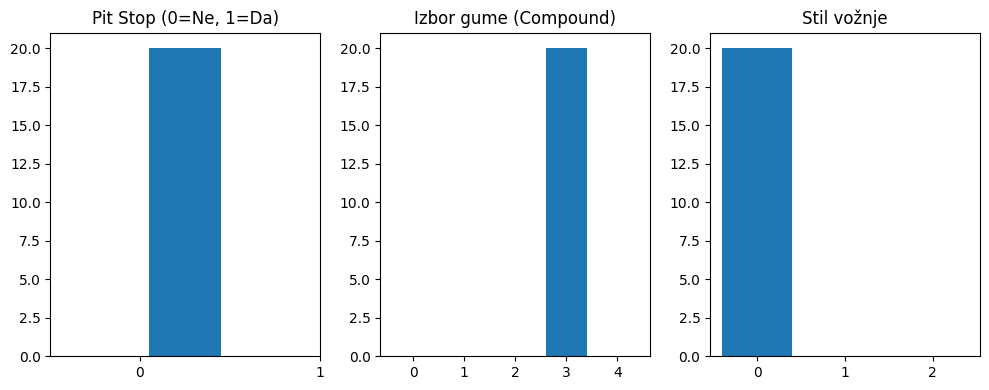

In [30]:
# === main.ipynb – Interaktivna biljeznica za testiranje F1 RL agenta ===

# Pokretanje FastAPI servera mora biti u drugom terminalu:
# uvicorn api:app --reload

# Ako fali paketa:
# pip install requests numpy matplotlib

import requests
import numpy as np
import matplotlib.pyplot as plt
import time

# Endpoint REST API-ja
url = "http://127.0.0.1:8000/predict_strategy"

# Simulacija jedne epizode
def simulate_episode(n_steps=20, verbose=True):
    rewards = []
    actions = []
    state = np.random.rand(15).tolist()

    for step in range(n_steps):
        response = requests.post(url, json={"state": state})
        data = response.json()
        action = data["action"]
        explanation = data.get("explanation", {})

        reward = sum(action) - 0.1 * np.random.rand()
        rewards.append(reward)
        actions.append(action)

        if verbose:
            print(f"Korak {step+1}:")
            print(f"State: {np.round(state, 2)}")
            print(f"Akcija: {action}")
            print(f"Objašnjenje: {explanation}")
            print(f"Reward: {reward:.2f}")
            print("-" * 40)

        # Ažuriraj stanje (dummy dinamika)
        state = (np.random.rand(15) * (0.5 + reward / 10)).tolist()
        time.sleep(0.1)  # simulacija vremenskog koraka

    return rewards, actions

# Pokreni simulaciju
rewards, actions = simulate_episode()

# === Graf: Reward po koraku ===
plt.figure(figsize=(10, 4))
plt.plot(rewards, marker='o')
plt.title("Simulirani reward agenta po koraku")
plt.xlabel("Korak")
plt.ylabel("Reward")
plt.grid(True)
plt.tight_layout()
plt.show()

# === Graf: Distribucija akcija ===
pit_list = [a[0] for a in actions]
comp_list = [a[1] for a in actions]
style_list = [a[2] for a in actions]

plt.figure(figsize=(10, 4))

plt.subplot(1, 3, 1)
plt.hist(pit_list, bins=2, rwidth=0.8)
plt.xticks([0, 1])
plt.title("Pit Stop (0=Ne, 1=Da)")

plt.subplot(1, 3, 2)
plt.hist(comp_list, bins=np.arange(6)-0.5, rwidth=0.8)
plt.xticks(range(5))
plt.title("Izbor gume (Compound)")

plt.subplot(1, 3, 3)
plt.hist(style_list, bins=np.arange(4)-0.5, rwidth=0.8)
plt.xticks([0, 1, 2])
plt.title("Stil vožnje")

plt.tight_layout()
plt.show()


In [26]:
import requests
import numpy as np
import matplotlib.pyplot as plt
import time

# === URL baze za FastAPI server ===
BASE_URL = "http://127.0.0.1:8000"

# === Generiranje dummy stanja (dimenzija npr. 15) ===
def generate_dummy_state(n=15):
    return (np.random.rand(n)).tolist()

# === 1. predict_strategy ===
def test_predict_strategy():
    url = f"{BASE_URL}/predict_strategy"
    state = generate_dummy_state()
    response = requests.post(url, json={"state": state})
    print("=== /predict_strategy ===")
    print("Input:", state)
    print("Response:", response.json())
    return response.json()

# === 2. predict_strategy_batch ===
def test_predict_strategy_batch():
    url = f"{BASE_URL}/predict_strategy_batch"
    states = [{"state": generate_dummy_state()}, {"state": generate_dummy_state()}]
    response = requests.post(url, json=states)
    print("\n=== /predict_strategy_batch ===")
    print("Input:", states)
    print("Response:", response.json())
    return response.json()


# === 3. explain_strategy ===
def test_explain_strategy():
    url = f"{BASE_URL}/explain_strategy"
    state = generate_dummy_state()
    response = requests.post(url, json={"state": state})
    print("\n=== /explain_strategy ===")
    print("Input:", state)
    print("Response:", response.json())
    return response.json()

# === Pokreni sve testove ===
predict_result = test_predict_strategy()
batch_result = test_predict_strategy_batch()
explanation_result = test_explain_strategy()


=== /predict_strategy ===
Input: [0.9682350714047914, 0.3461039155038308, 0.07897362773344241, 0.6918785899212361, 0.22236358306958026, 0.8219127978096182, 0.9870544738011235, 0.2669122727241642, 0.35047918444789095, 0.8780553293765105, 0.7759190403450171, 0.42757189096057835, 0.6410415339280354, 0.1179420013649275, 0.6332316428921874]
Response: {'action': [0, 3, 0], 'explanation': {'pit': 'Nema pit stopa – dovoljno guma', 'compound': 'Compound kod: 3', 'style': 'Konzervativno'}}

=== /predict_strategy_batch ===
Input: [{'state': [0.5184446393758351, 0.3047603105029397, 0.5701817118165363, 0.10904044496727205, 0.21358560385298653, 0.9476106771856435, 0.8761859845496706, 0.342260058685775, 0.6901773016330542, 0.6123870898065064, 0.1561208511906359, 0.9567543170379963, 0.6577248860815308, 0.24010465101993272, 0.7298563246108177]}, {'state': [0.7105662946633797, 0.6802290336743734, 0.8458763535924093, 0.14925368770642777, 0.2575885173343925, 0.9862901999048918, 0.25248787518896587, 0.5846

Točnost predikcije PIT:    0.97
Točnost izbora GUME:       0.30
Točnost STILA VOŽNJE:      0.41


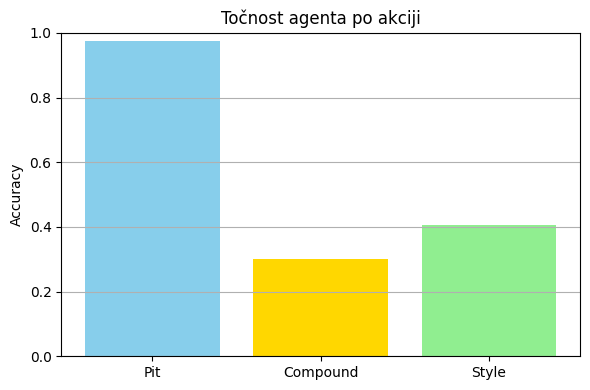

In [ ]:
import numpy as np
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
from stable_baselines3 import PPO

# === Učitaj model i podatke ===
model = PPO.load("saved_models/ppo_f1_rl.zip")
obs_array = np.load("data/obs_array.npy")
true_actions = np.load("data/true_actions.npy")

# === Predikcije i stvarne akcije ===
pred_pits, pred_comps, pred_styles = [], [], []
true_pits, true_comps, true_styles = [], [], []

for i in range(len(obs_array)):
    obs = obs_array[i].reshape(1, -1)
    
    # Predikcija pomoću modela
    action, _ = model.predict(obs, deterministic=True)

    # Uvjetna obrada da se osigura pravi format
    action = action[0] if isinstance(action[0], (list, np.ndarray)) else action

    pred_pits.append(action[0])
    pred_comps.append(action[1])
    pred_styles.append(action[2])

    true_pits.append(true_actions[i][0])
    true_comps.append(true_actions[i][1])
    true_styles.append(true_actions[i][2])


# === Izračunaj točnost ===
acc_pit = accuracy_score(true_pits, pred_pits)
acc_comp = accuracy_score(true_comps, pred_comps)
acc_style = accuracy_score(true_styles, pred_styles)

print(f"Točnost predikcije PIT:    {acc_pit:.2f}")
print(f"Točnost izbora GUME:       {acc_comp:.2f}")
print(f"Točnost STILA VOŽNJE:      {acc_style:.2f}")

# === Vizualizacija točnosti po akciji ===
labels = ["Pit", "Compound", "Style"]
accuracies = [acc_pit, acc_comp, acc_style]

plt.figure(figsize=(6, 4))
plt.bar(labels, accuracies, color=["skyblue", "gold", "lightgreen"])
plt.ylim(0, 1)
plt.title("Točnost agenta po akciji")
plt.ylabel("Accuracy")
plt.grid(axis='y')
plt.tight_layout()
plt.show()
